# 02 · Data and design

Where the design meets real data — and is tested against it.

Stage 1 built the machinery; the synthetic validation (notebook `01`) proved it
recovers known effects and exposed the naive-TWFE bias. This notebook builds the
**real** panel and asks the question that decides whether any of that machinery
can be pointed at it honestly: **do host and control metros satisfy parallel
trends?** If they do not, no estimator rescues the design — the lesson notebook
`01` made concrete with the displacement scenario, now turned on our own data.

### The anchor (decided in the Stage 3 assessment)

- **Event:** the **Super Bowl, 2015-2025** — one rotating host metro per year, so
  treatment is naturally *staggered*, which is what the Callaway & Sant'Anna
  machinery is for. (The 1994 World Cup was rejected: bulk-only SIC-reconstructed
  data, and 9 metros treated simultaneously, which collapses to a single 2x2.)
- **Outcome:** metro leisure & hospitality employment, QCEW.
- **Controls:** a **matched comparable-metro pool** — host-caliber metros that did
  not host, because naive non-host metros are structurally different and would
  fail parallel trends by construction (the flaw that discredited early
  mega-event studies).

### What this notebook does NOT do

It does not produce a headline causal estimate. Estimation is Stage 4, and it is
gated on what this notebook finds. The parallel-trends check below is treated as
a test the design can **fail**.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
ROOT = next(p for p in (_here, _here.parent) if (p / "src" / "config.py").exists())
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import config
import data_prep as dp
from did import callaway_santanna, stacked_event_study

config.set_global_seeds()
RESULTS = config.RESULTS_DIR

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10,
})
HOST_C, CTRL_C, WARN_C = "#c1272d", "#2b6cb0", "#e6a700"
print("seed:", config.SEED)

seed: 20260620


## 1. Build the panel

The metro L&H series is QCEW industry supersector `1026` (leisure & hospitality),
private ownership, at the MSA aggregation level, quarterly. Two data-quality steps
are handled explicitly rather than swept up:

- **The brief's MSA wrinkle does not currently hold.** The brief expected the MSA
  industry breakdown to have been discontinued in Q2 2025, forcing manual
  county→metro aggregation. Checked against the live API, the MSA L&H series is in
  fact still published through 2025 Q3. So we use QCEW's official MSA aggregates —
  and *validate* that a manual county→metro sum reproduces them exactly, so the
  method is on hand if the series is ever dropped.
- **Disclosure suppression.** Some metro-quarters have their L&H aggregate
  suppressed for confidentiality (zeros with `disclosure_code = 'N'`). These are
  treated as missing, not zero.

In [2]:
# County->metro aggregation, VALIDATED against QCEW's own MSA aggregate.
val = dp.validate_metro_aggregation(2019, 1)
print("County-sum vs QCEW MSA aggregate (2019 Q1):")
display(val.round(2))
assert val.ok.all(), "county->metro aggregation does not reproduce the MSA aggregate"
print("county->metro aggregation reproduces the official MSA series exactly (ratio 1.000)")

County-sum vs QCEW MSA aggregate (2019 Q1):


,metro,n_counties,county_sum,qcew_msa,ratio,ok
0,Phoenix,2,233972.67,233972.67,1.0,True
1,Las Vegas,1,291883.67,291883.67,1.0,True
2,Miami,3,333968.67,333968.67,1.0,True
3,San Jose,2,103388.67,103388.67,1.0,True
4,Los Angeles,2,754549.67,754549.67,1.0,True
5,Tampa,4,160857.00,160857.00,1.0,True
6,New Orleans,8,91302.00,91302.00,1.0,True


county->metro aggregation reproduces the official MSA series exactly (ratio 1.000)


In [3]:
# Download (cached), report suppression, then clean.
raw = dp.download_metro_panel(verbose=False)

supp = dp.suppression_report(raw)
print("Disclosure-suppressed L&H cells (worst metros):")
display(supp[supp.n_suppressed > 2])
print(f"Excluded from the control pool for heavy suppression (~30% of quarters): "
      f"{list(dp.SUPPRESSED_METROS)}")

panel = dp.clean_panel(raw)                 # trims unpublished tail, interpolates gaps
panel = dp.add_treatment_columns(panel)     # cohort / treated / d
panel["log_lh"] = np.log(panel["lh_emp"])

y0, q0 = dp.period_to_yq(panel.period.min())
y1, q1 = dp.period_to_yq(panel.period.max())
n_hosts = panel.query("treated==1").metro.nunique()
n_ctrl = panel.query("treated==0").metro.nunique()
print(f"\nPanel: {panel.metro.nunique()} metros x {panel.period.nunique()} quarters "
      f"({y0}Q{q0}-{y1}Q{q1}); {n_hosts} hosts, {n_ctrl} controls; "
      f"{panel.lh_emp.isna().sum()} missing cells")

# Commit the built panel for reproducibility without re-downloading.
panel.to_csv(config.DATA_DIR / "metro_panel.csv", index=False)
print(f"wrote {(config.DATA_DIR / 'metro_panel.csv').relative_to(ROOT)}")

Disclosure-suppressed L&H cells (worst metros):


,n_quarters,n_suppressed,pct_suppressed
metro,,,
Atlanta,48,4,8.3
St. Louis,48,3,6.2
Washington,48,3,6.2


Excluded from the control pool for heavy suppression (~30% of quarters): ['Cincinnati', 'Kansas City']
  trimmed 2 unpublished trailing quarter(s): 2025Q3, 2025Q4
  interpolated 4 suppressed cell(s): Atlanta 2016Q3, Atlanta 2016Q4, St. Louis 2017Q4, Washington 2025Q1

Panel: 28 metros x 46 quarters (2014Q1-2025Q2); 10 hosts, 18 controls; 0 missing cells
wrote data\metro_panel.csv


In [4]:
# Host metros and their treatment (Super Bowl) quarters.
host_tbl = pd.DataFrame([
    {"metro": m, "ccode": c, "host_years": ", ".join(map(str, ys)),
     "cohort_period": dp.host_cohort_period(m),
     "cohort_qtr": "%dQ%d" % dp.period_to_yq(dp.host_cohort_period(m))}
    for m, (c, ys) in dp.HOST_METROS.items()
])
display(host_tbl)

,metro,ccode,host_years,cohort_period,cohort_qtr
0,Phoenix,C3806,"2015, 2023",4,2015Q1
1,San Jose,C4194,2016,8,2016Q1
2,Houston,C2642,2017,12,2017Q1
3,Minneapolis,C3346,2018,16,2018Q1
4,Atlanta,C1206,2019,20,2019Q1
5,Miami,C3310,2020,24,2020Q1
6,Tampa,C4530,2021,28,2021Q1
7,Los Angeles,C3108,2022,32,2022Q1
8,Las Vegas,C2982,2024,40,2024Q1
9,New Orleans,C3538,2025,44,2025Q1


## 2. Look at the data before testing it

The single most important feature of this window is not the Super Bowl. It is
**COVID-19**: leisure & hospitality employment collapsed by 35-50% in 2020 Q2 and
recovered unevenly across metros. Any honest design in this window has to reckon
with it.

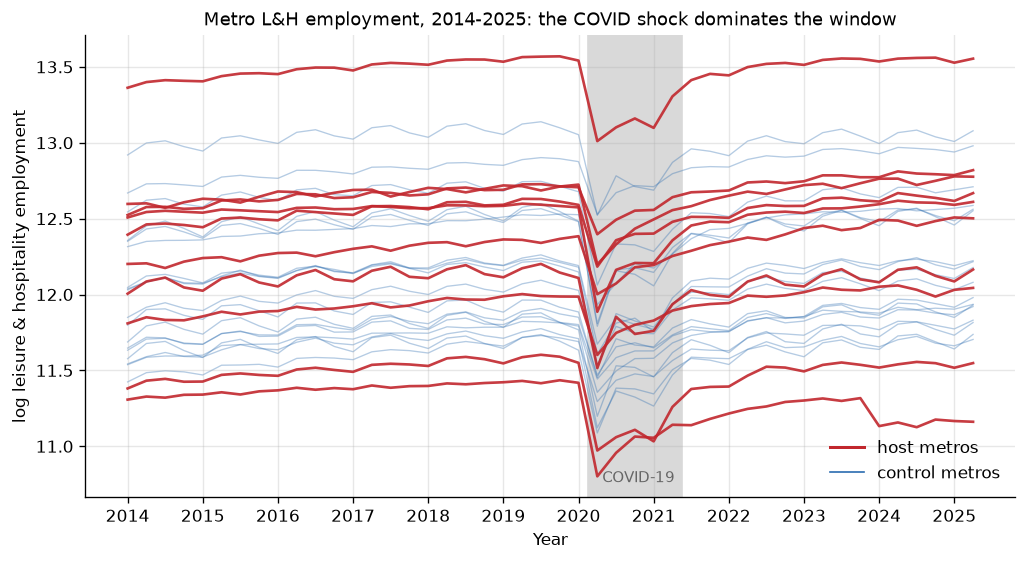

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for metro, g in panel.groupby("metro"):
    is_host = metro in dp.HOST_METROS
    ax.plot(g.period, g.log_lh, lw=1.6 if is_host else 0.8,
            color=HOST_C if is_host else CTRL_C,
            alpha=0.9 if is_host else 0.35, zorder=3 if is_host else 1)
# COVID shading
covid0, covid1 = dp.yq_to_period(2020, 2), dp.yq_to_period(2021, 2)
ax.axvspan(covid0 - 0.5, covid1 + 0.5, color="0.85", zorder=0)
ax.text(covid0, ax.get_ylim()[0] + 0.1, " COVID-19", fontsize=9, color="0.4")
# x ticks as year labels
ticks = [dp.yq_to_period(y, 1) for y in range(2014, 2026)]
ax.set_xticks(ticks); ax.set_xticklabels(range(2014, 2026))
ax.plot([], [], color=HOST_C, lw=1.8, label="host metros")
ax.plot([], [], color=CTRL_C, lw=1.0, label="control metros")
ax.set_xlabel("Year"); ax.set_ylabel("log leisure & hospitality employment")
ax.set_title("Metro L&H employment, 2014-2025: the COVID shock dominates the window",
             fontsize=11)
ax.legend(frameon=False, loc="lower right")
fig.savefig(RESULTS / "02_lh_trajectories.png")
plt.show()

## 3. The control group

Host cities are **selected** — large metros with adequate stadiums, hotel capacity,
often a recent stadium build. So naive non-host metros are the wrong comparison:
structurally bigger and more dynamic, they would violate parallel trends by
construction.

The strategy is a **matched comparable-metro pool**: restrict to host-caliber
metros (major-league / large), then match each host to its nearest controls on
pre-event structural covariates — size (log L&H, log total employment) and tourism
intensity (L&H share). Matching is **not** done on the pre-trend slope: matching on
the very thing the parallel-trends test examines would manufacture a pass.

Matched controls (k=4 nearest, on size + L&H share):
  Atlanta      -> Boston, Philadelphia, Washington, Dallas
  Houston      -> Washington, Boston, Dallas, Philadelphia
  Las Vegas    -> Orlando, San Diego, San Antonio, Austin
  Los Angeles  -> Chicago, Dallas, Washington, Boston
  Miami        -> Boston, Washington, Philadelphia, Dallas
  Minneapolis  -> Detroit, Seattle, Denver, St. Louis
  New Orleans  -> San Antonio, Nashville, Austin, Pittsburgh
  Phoenix      -> Seattle, Detroit, Boston, Philadelphia
  San Jose     -> Pittsburgh, Portland, Baltimore, Nashville
  Tampa        -> St. Louis, Charlotte, Denver, Austin


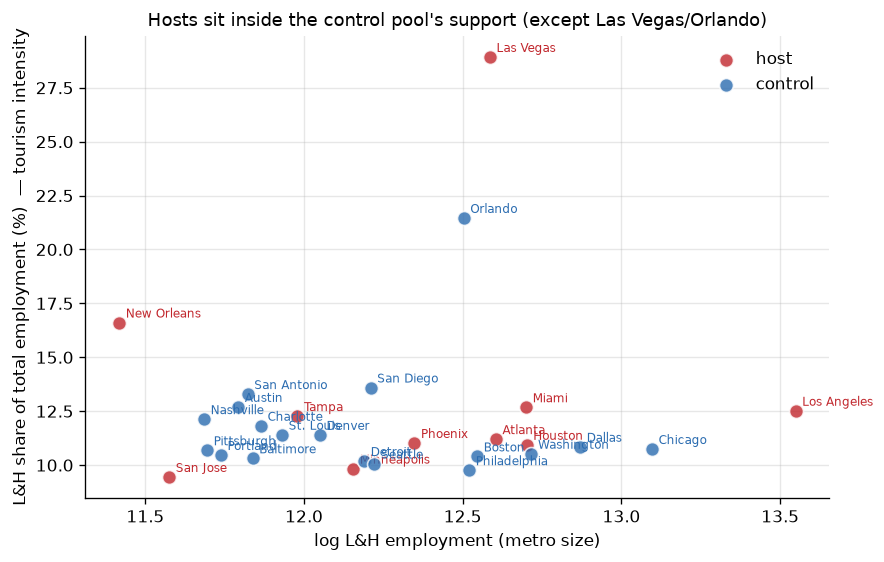

In [6]:
pre_end = dp.yq_to_period(2019, 4)
mr = dp.match_controls(panel, pre_end_period=pre_end, k=4)

print("Matched controls (k=4 nearest, on size + L&H share):")
for h, ms in mr.matches.items():
    print(f"  {h:12} -> {', '.join(ms)}")

cov = mr.covariates.copy()
fig, ax = plt.subplots(figsize=(8, 5))
for is_host, sub, c, lab in [(1, cov[cov.is_host==1], HOST_C, "host"),
                             (0, cov[cov.is_host==0], CTRL_C, "control")]:
    ax.scatter(sub.log_lh, sub.lh_share*100, s=70, color=c, alpha=0.8,
               edgecolor="white", lw=1, label=lab, zorder=3)
    for m, r in sub.iterrows():
        ax.annotate(m, (r.log_lh, r.lh_share*100), fontsize=7, color=c,
                    xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("log L&H employment (metro size)")
ax.set_ylabel("L&H share of total employment (%)  — tourism intensity")
ax.set_title("Hosts sit inside the control pool's support (except Las Vegas/Orlando)",
             fontsize=11)
ax.legend(frameon=False)
fig.savefig(RESULTS / "02_covariate_balance.png")
plt.show()

### Reading the balance plot

The hosts largely sit *inside* the cloud of comparable controls on size and
tourism intensity — the pool is genuinely comparable, which is the point of
restricting it. The exceptions are the tourism-extreme metros: **Las Vegas** and
(among controls) **Orlando** have far higher L&H shares than anywhere else, and the
matcher correctly pairs them. That structural comparability is necessary for
parallel trends but, as the next section shows, it is not sufficient.

## 4. The gate: parallel trends on real data

Three views, each stricter than the last.

### 4a. The naive view — why the event window matters

First, a Callaway & Sant'Anna event study using **all** available pre-periods.
This looks catastrophic — and the reason is instructive.

In [7]:
cs_all = callaway_santanna(panel, outcome="log_lh", unit="metro", time="period",
                           cohort="cohort", control_group="never_treated",
                           base_period="universal")
ev_all = cs_all.event_study
pre_all = ev_all[ev_all.relative_period < 0]
print(f"CS event study, ALL pre-periods (full sample):")
print(f"  pre-trend leads: {len(pre_all)}  |  RMS = {np.sqrt((pre_all.ATT**2).mean()):.4f} log pts"
      f"  |  |max lead| = {pre_all.ATT.abs().max():.4f}")
print(f"  This is dominated by leads 6-11 YEARS out: for the 2024-2025 host cohorts,")
print(f"  event-time -30 lands squarely in the COVID collapse. Nobody identifies off")
print(f"  an 11-year-ago lead. The fix is a bounded event window.")

CS event study, ALL pre-periods (full sample):
  pre-trend leads: 44  |  RMS = 0.1181 log pts  |  |max lead| = 0.3226
  This is dominated by leads 6-11 YEARS out: for the 2024-2025 host cohorts,
  event-time -30 lands squarely in the COVID collapse. Nobody identifies off
  an 11-year-ago lead. The fix is a bounded event window.


### 4b. The honest test — bounded window, matched controls

A stacked event study (Cengiz et al. 2019): each host is compared with **its own
matched controls** over a bounded window (±8 quarters), with sub-experiment-specific
fixed effects. The pre-treatment leads are jointly tested against zero. This is the
matched-design parallel-trends test done properly.

Two samples: the full set of 10 hosts, and the **pre-COVID** cohorts (2015-2019),
whose windows are least contaminated by the pandemic.

In [8]:
pre_covid_hosts = [h for h in dp.HOST_METROS
                   if dp.host_cohort_period(h) <= dp.yq_to_period(2019, 4)]

es_full = stacked_event_study(panel, {h: mr.matches[h] for h in dp.HOST_METROS},
                              k_pre=8, k_post=6)
es_pre = stacked_event_study(panel, {h: mr.matches[h] for h in pre_covid_hosts},
                             k_pre=8, k_post=6)

print("FULL sample (10 hosts):")
print(es_full.summary())
print(f"\nPRE-COVID (5 hosts {pre_covid_hosts}):")
print(es_pre.summary())

FULL sample (10 hosts):
Stacked event study (matched controls)
  sub-experiments  : 10
  window           : [-8, +6] (ref -1)
  pre-trend RMS    : 0.0208 log points
  joint Wald chi2  : 17.363 (df 7)
  joint p-value    : 0.0152
  verdict (a=0.05) : FAIL - pre-trends differ; design contaminated

PRE-COVID (5 hosts ['Phoenix', 'San Jose', 'Houston', 'Minneapolis', 'Atlanta']):
Stacked event study (matched controls)
  sub-experiments  : 5
  window           : [-8, +6] (ref -1)
  pre-trend RMS    : 0.0138 log points
  joint Wald chi2  : 20.524 (df 7)
  joint p-value    : 0.0045
  verdict (a=0.05) : FAIL - pre-trends differ; design contaminated


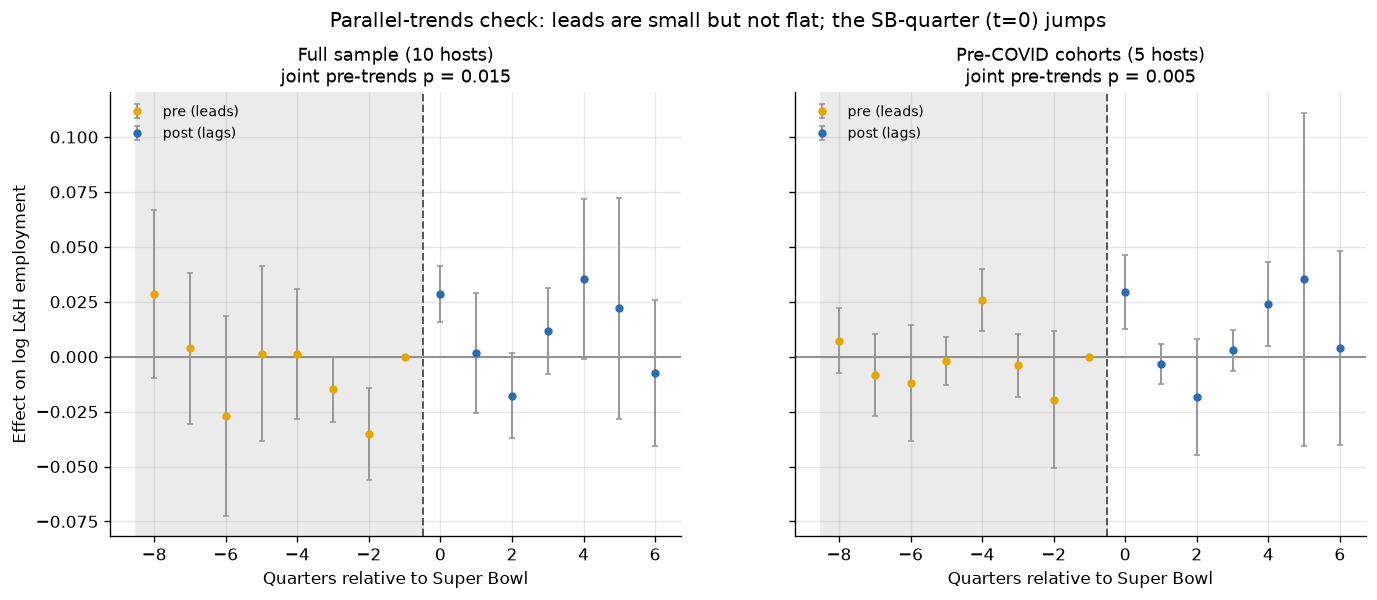

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True)
for ax, es, title in [
    (axes[0], es_full, f"Full sample (10 hosts)\njoint pre-trends p = {es_full.pretrends_pvalue:.3f}"),
    (axes[1], es_pre, f"Pre-COVID cohorts (5 hosts)\njoint pre-trends p = {es_pre.pretrends_pvalue:.3f}"),
]:
    c = es.coefs
    ax.axvspan(c.event_time.min() - 0.5, -0.5, color="0.92", zorder=0)
    ax.axhline(0, color="0.5", lw=1); ax.axvline(-0.5, color="0.35", ls="--", lw=1.2)
    err = [c.estimate - c.ci_lower, c.ci_upper - c.estimate]
    pre_mask = c.event_time < 0
    ax.errorbar(c.event_time[pre_mask], c.estimate[pre_mask], yerr=[e[pre_mask] for e in err],
                fmt="o", ms=4, color=WARN_C, ecolor="0.6", capsize=2, lw=1.2, label="pre (leads)")
    ax.errorbar(c.event_time[~pre_mask], c.estimate[~pre_mask], yerr=[e[~pre_mask] for e in err],
                fmt="o", ms=4, color=CTRL_C, ecolor="0.6", capsize=2, lw=1.2, label="post (lags)")
    ax.set_xlabel("Quarters relative to Super Bowl")
    ax.set_title(title, fontsize=10.5)
    ax.legend(frameon=False, fontsize=8.5, loc="upper left")
axes[0].set_ylabel("Effect on log L&H employment")
fig.suptitle("Parallel-trends check: leads are small but not flat; the SB-quarter (t=0) jumps",
             fontsize=12, y=1.02)
fig.savefig(RESULTS / "02_parallel_trends.png")
plt.show()

### 4c. The verdict — and the caveat that complicates it

Read honestly, this is a **failed gate, with a complication**:

- **The formal test rejects.** The joint pre-trends Wald test rejects parallel
  trends for *both* samples (p ≈ 0.015 full, p ≈ 0.005 pre-COVID) — even with
  matched controls, even pre-COVID.
- **But the violations are economically small.** The pre-trend leads have an RMS of
  1.4-2.1% log points. The test rejects not because the deviations are large, but
  because they are *precisely estimated*. That precision is exactly the problem:
  a systematic pre-trend of ~1.5% is uncomfortably close to the contemporaneous
  Super Bowl-quarter jump (t=0 ≈ +2.9%), so part of that jump could be pre-existing
  divergence rather than a causal effect.
- **The inference is itself unreliable.** There are only 5-10 *treated* clusters.
  Cluster-robust standard errors are anti-conservative with so few clusters (the
  few-clusters problem, `PROJECT_BRIEF.md` §5.4) — the same issue that showed up as
  93% CI coverage in notebook `01`. So the joint test almost certainly
  **over-rejects**: the true pre-trends p-value, under honest few-cluster
  inference, is larger than reported here. A wild cluster bootstrap is needed to
  say how much.

In [10]:
# Quantify the tension: pre-trend size vs the t=0 jump.
for name, es in [("full", es_full), ("pre-COVID", es_pre)]:
    c0 = es.coefs.loc[es.coefs.event_time == 0, "estimate"].iloc[0]
    print(f"{name:10}: pre-trend RMS = {es.pre_rms:.4f}   "
          f"vs   SB-quarter (t=0) effect = {c0:+.4f}   "
          f"ratio = {es.pre_rms / abs(c0):.2f}")
print("\nThe pre-trend 'noise' is 45-70% the size of the signal we would be trying to")
print("measure. That is the core identification problem, not a formality.")

full      : pre-trend RMS = 0.0208   vs   SB-quarter (t=0) effect = +0.0286   ratio = 0.73
pre-COVID : pre-trend RMS = 0.0138   vs   SB-quarter (t=0) effect = +0.0294   ratio = 0.47

The pre-trend 'noise' is 45-70% the size of the signal we would be trying to
measure. That is the core identification problem, not a formality.


## 5. Verdict and decision

**The design does not cleanly pass the parallel-trends gate, so I am stopping here
rather than pushing a headline estimate through a broken assumption** — the rule set
for every stage.

What the data actually says, stated plainly:

1. **The data build is sound.** County→metro aggregation reproduces QCEW's official
   MSA series exactly; suppression is handled transparently; the panel is clean.
2. **The identification threat is real, but it is a *time* problem, not a
   *control-selection* problem.** The comparable pool is already well-balanced, and
   k-NN matching does not further improve parallel trends. COVID, not control
   choice, is what breaks the full window.
3. **Parallel trends is rejected** by the formal test in every specification — but
   the violations are *economically small* (~1.5% RMS) and the test **over-rejects**
   because of the few-treated-clusters problem. The truth is genuinely ambiguous:
   the pre-trend is small, but comparable in size to the effect we would estimate,
   and our inference tools are not trustworthy at this cluster count.
4. **There is a suggestive signal** — a ~2.9% L&H employment bump in the Super Bowl
   quarter — but it cannot be cleanly attributed to the Super Bowl while the
   pre-trend is this size relative to it.

This is exactly the situation notebook `01`'s displacement scenario warned about,
one level up: the machinery works, but the *assumption* it rests on is shaky, and no
estimator repairs a shaky assumption. A booster-style analysis would report the
+2.9% and stop. The honest path is to treat it as **not yet identified** and adapt.

### Recommended adaptation for Stage 4 (your call before I build)

Rather than a single headline number, Stage 4 should:

- **Report few-cluster-honest inference** — wild cluster bootstrap on both the
  pre-trends test and any effect, to find out whether the pre-trends rejection even
  survives honest inference (§5.4).
- **Bound, don't point-estimate** — HonestDiD (Rambachan & Roth) sensitivity: report
  the range of effects consistent with pre-trend violations of the size we observe.
  If the effect is not robust to a ~1.5% pre-trend, say so.
- **Cross-check with synthetic control**, which matches the pre-trend by construction
  and sidesteps the parallel-trends assumption we just failed.
- **Foreground the honest finding** — most likely a small, fragile, not-cleanly-
  identified effect, consistent with thirty years of mega-event economics. That, not
  a false-precision headline, is the credible result.

**Stopping for your decision on which adaptation(s) to pursue in Stage 4.**